# 🚢 Titanic Survival Prediction using K-Nearest Neighbors (KNN)
**Objective:** Predict passenger survival on the Titanic using the **K-Nearest Neighbors (KNN)** algorithm. KNN is a distance-based classifier, making **Feature Scaling** a critical and mandatory step in our `scikit-learn` preprocessing pipeline.

In [7]:
# 1. Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(" Libraries Imported Successfully")

 Libraries Imported Successfully


---
### 📂 Step 1: Load Data & Smart Cleaning
Consistent with our robust methodology, we handle missing data smartly rather than dropping entire rows unnecessarilly.

In [8]:
# Load Dataset
df = pd.read_csv('titanic_data.csv')

# Drop highly missing or redundant columns to prevent Data Leakage
columns_to_drop = ['deck', 'alive', 'class', 'embark_town', 'who']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Drop exact duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Cleaned Dataset Shape: {df.shape}")
display(df.head(3))

Cleaned Dataset Shape: (778, 10)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,True,False
1,1,1,female,38.0,1,0,71.2833,C,False,False
2,1,3,female,26.0,0,0,7.9250,S,False,True


---
### ✂️ Step 2: Feature Separation & Train-Test Split

In [9]:
# Separate Features (X) and Target (y)
X = df.drop('survived', axis=1)
y = df['survived']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Dynamically identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns

---
### 🏗️ Step 3: Build the KNN Classification Pipeline
**Crucial Note for KNN:** KNN computes the Euclidean distance between data points. If we don't scale features like `fare` (which can be 100s) and `age` (which is typically <100), the larger numbers will dominate the distance calculation. Our pipeline ensures `StandardScaler` is applied.

In [10]:
# 1. Numerical Pipeline (Impute with median -> Scale)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) # EXTREMELY IMPORTANT FOR KNN
])

# 2. Categorical Pipeline (Impute with mode -> One-Hot Encode)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# 4. Full Pipeline with KNN Classifier (Using K=5 as default)
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2))
])

print(" KNN Pipeline Built Successfully")

 KNN Pipeline Built Successfully


---
### 🚀 Step 4: Train, Evaluate, and Visualize the Confusion Matrix

🏆 KNN Model Accuracy (K=5): 79.49%

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        91
           1       0.79      0.69      0.74        65

    accuracy                           0.79       156
   macro avg       0.79      0.78      0.78       156
weighted avg       0.79      0.79      0.79       156



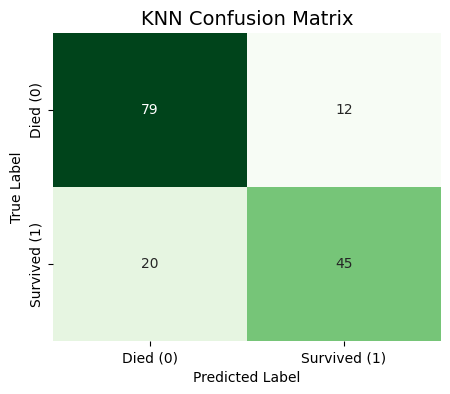

In [11]:
# Train the Pipeline
knn_pipeline.fit(X_train, y_train)

# Predict on Test Data
y_pred = knn_pipeline.predict(X_test)

# Evaluation Metrics
print(f"🏆 KNN Model Accuracy (K=5): {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("📄 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Died (0)', 'Survived (1)'],
            yticklabels=['Died (0)', 'Survived (1)'])
plt.title('KNN Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

---
### 🔍 Step 5: Hyperparameter Tuning (Finding the Best 'K')
How do we know if $K=5$ is the best choice? Let's loop through different values of $K$, train the model, and plot the accuracy to visually identify the optimal number of neighbors.

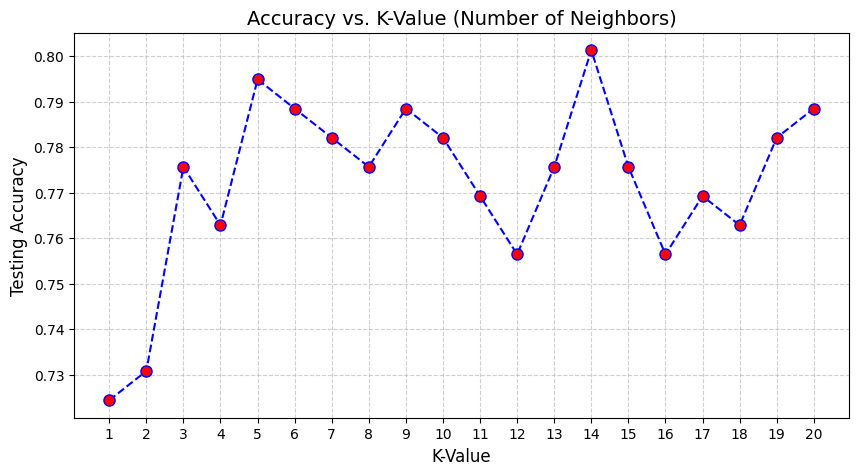

 The optimal number of neighbors (K) based on testing accuracy is: 14


In [12]:
# Let's test K values from 1 to 20
k_values = range(1, 21)
accuracies = []

for k in k_values:
    # Update the n_neighbors parameter in the existing pipeline
    knn_pipeline.set_params(classifier__n_neighbors=k)
    
    # Train and evaluate
    knn_pipeline.fit(X_train, y_train)
    y_pred_k = knn_pipeline.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_k))

# Visualizing the results
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed', color='blue', markersize=8, markerfacecolor='red')
plt.title('Accuracy vs. K-Value (Number of Neighbors)', fontsize=14)
plt.xlabel('K-Value', fontsize=12)
plt.ylabel('Testing Accuracy', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Find the best K
best_k = k_values[accuracies.index(max(accuracies))]
print(f" The optimal number of neighbors (K) based on testing accuracy is: {best_k}")